In [1]:
import rasterio
import pandas as pd
import numpy as np

# Buka file GeoTIFF
tif_file = r"D:\ITB\TA\Data\Parameter\04. Roughness\mola_roughness_2.4km_numeric.tif"

with rasterio.open(tif_file) as src:
    
    # Ambil data raster band pertama
    band = src.read(1)
    
    # Ambil ukuran raster
    rows, cols = band.shape
    
    data = []

    # Loop semua pixel
    for row in range(rows):
        for col in range(cols):
            
            # Nilai pixel
            value = band[row, col]
            
            # Skip nilai kosong (NoData)
            if value == src.nodata:
                continue
            
            # Konversi pixel ke koordinat
            lon, lat = src.xy(row, col)
            
            data.append({
                "Longitude": lon,
                "Latitude": lat,
                "Roughness": value
            })

# Ubah ke dataframe
df = pd.DataFrame(data)

# Simpan CSV
df.to_csv("roughness_2.4km_bener.csv", index=False)

print("Selesai!")
print(df.head())

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


Selesai!
   Longitude  Latitude  Roughness
0        0.5       0.5          0
1        1.5       0.5          0
2        2.5       0.5          0
3        3.5       0.5          0
4        4.5       0.5          0


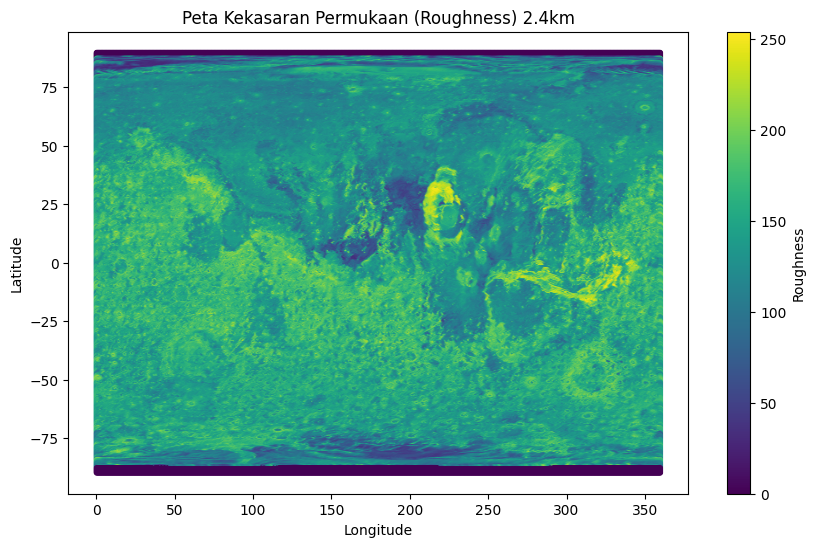

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Baca data dari CSV
df_bersih = pd.read_csv(r"D:\ITB\TA\Ngolah Data\05. Roughness\roughness_2.4km_bener.csv")

df_bersih["Longitude"] = df_bersih["Longitude"] * 360 / 720
df_bersih["Latitude"] =90 - (df_bersih["Latitude"] * 180 / 360)


# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_bersih["Longitude"], df_bersih["Latitude"], c=df_bersih["Roughness"], cmap="viridis", s=10)
plt.colorbar(label="Roughness")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Kekasaran Permukaan (Roughness) 2.4km")


plt.show()

In [2]:
df_after0 = df_bersih[(df_bersih["Roughness"] >= 0)]
print(df_after0.head())

   Longitude  Latitude  Roughness
0       0.25     89.75          0
1       0.75     89.75          0
2       1.25     89.75          0
3       1.75     89.75          0
4       2.25     89.75          0


In [4]:
counts_after0 = df_after0["Roughness"].value_counts().sort_index()

print(counts_after0)

Roughness
0      6917
26        9
27       11
28       15
29       26
       ... 
250      11
251      10
252       4
253       1
254       2
Name: count, Length: 230, dtype: int64


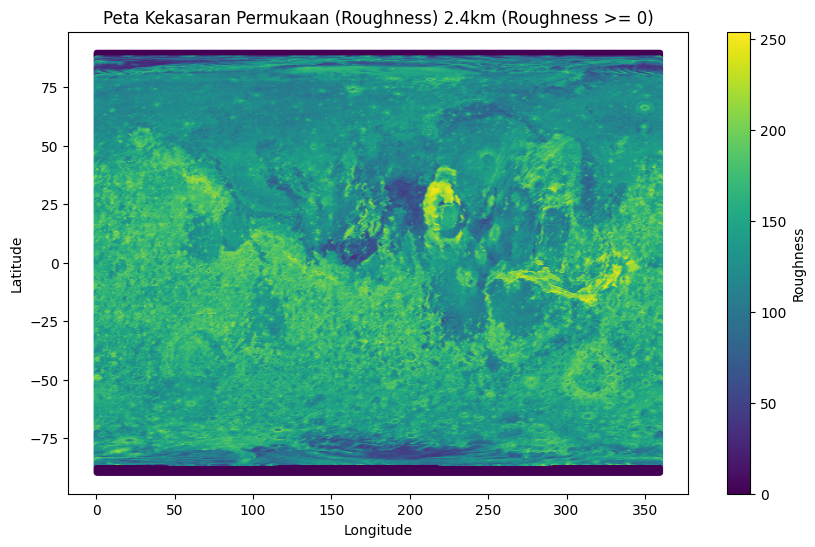

In [6]:
# Plot data
plt.figure(figsize=(10, 6))
plt.scatter(df_after0["Longitude"], df_after0["Latitude"], c=df_after0["Roughness"], cmap="viridis", s=10)
plt.colorbar(label="Roughness")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Peta Kekasaran Permukaan (Roughness) 2.4km (Roughness >= 0)")


plt.show()

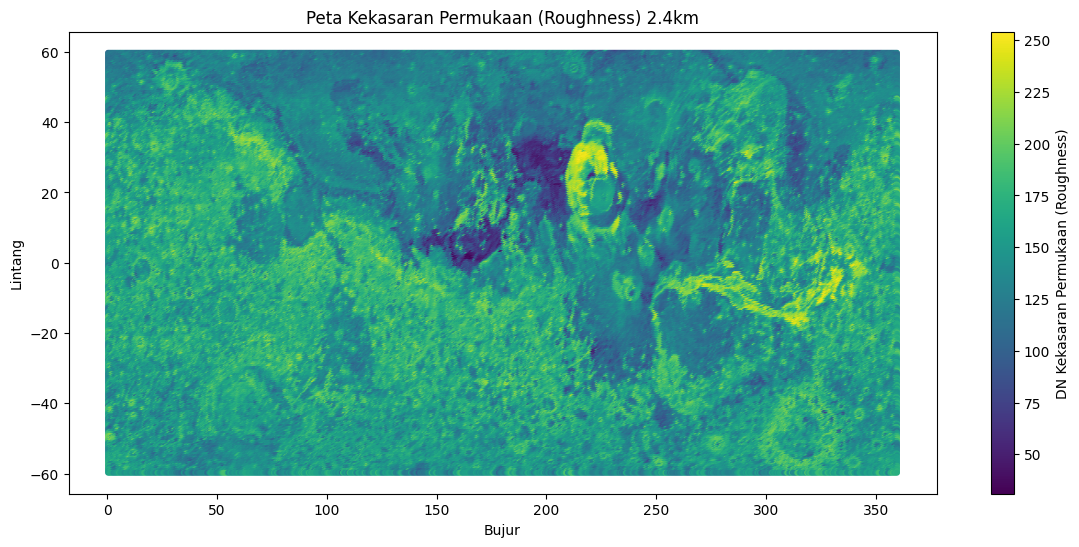

In [3]:
df_nonkutub = df_after0[(df_after0["Latitude"] < 60) & (df_after0["Latitude"] > -60)]
plt.figure(figsize=(14, 6))
plt.scatter(df_nonkutub["Longitude"], df_nonkutub["Latitude"], c=df_nonkutub["Roughness"], cmap="viridis", s=10)
plt.colorbar(label="DN Kekasaran Permukaan (Roughness)")
plt.xlabel("Bujur")
plt.ylabel("Lintang")
plt.title("Peta Kekasaran Permukaan (Roughness) 2.4km")
# balik sumbu y
plt.show()